# 🚢 Titanic Dataset — Exploratory Data Analysis (EDA)

**Author:** Python & AI Training Course  
**Dataset:** [Titanic – Machine Learning from Disaster](https://www.kaggle.com/c/titanic)  
**Date:** June 2026

---

## Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the famous **Titanic dataset**.  
We will uncover trends, patterns, and insights about passenger survival using:

- **Pandas** for data loading and manipulation  
- **Matplotlib & Seaborn** for visualisations  
- Statistical summaries and correlation analysis

### Key Questions We'll Answer
1. What was the overall survival rate?  
2. Did passenger class (Pclass) affect survival odds?  
3. How did gender influence survival?  
4. What role did age and fare play?  
5. Are there correlations between features?


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Plot aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [2]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv("titanic.csv")

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


Dataset shape: 891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Dataset Overview

In [3]:
# Data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# Statistical summary
df.describe(include="all").round(2)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.00,891.00,891.00,891,891,714.00,891.00,891.00,891,891.00,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.00,0.38,2.31,NaN,NaN,29.70,0.52,0.38,NaN,32.20,NaN,NaN
std,257.35,0.49,0.84,NaN,NaN,14.53,1.10,0.81,NaN,49.69,NaN,NaN
min,1.00,0.00,1.00,NaN,NaN,0.42,0.00,0.00,NaN,0.00,NaN,NaN
25%,223.50,0.00,2.00,NaN,NaN,20.12,0.00,0.00,NaN,7.91,NaN,NaN
50%,446.00,0.00,3.00,NaN,NaN,28.00,0.00,0.00,NaN,14.45,NaN,NaN
75%,668.50,1.00,3.00,NaN,NaN,38.00,1.00,0.00,NaN,31.00,NaN,NaN


## 2. Missing Value Analysis

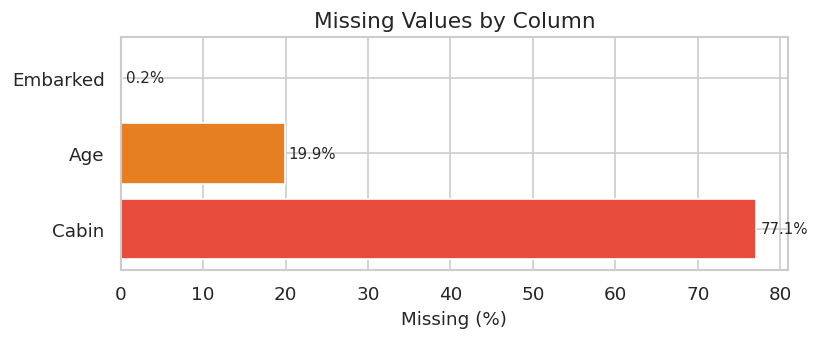

          Missing Count  Missing %
Cabin               687       77.1
Age                 177       19.9
Embarked              2        0.2


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(missing_df.index, missing_df["Missing %"], color=["#e74c3c","#e67e22","#f1c40f"])
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values by Column")
for bar, val in zip(bars, missing_df["Missing %"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("missing_values.png", bbox_inches="tight")
plt.show()
print(missing_df.to_string())


## 3. Overall Survival Rate

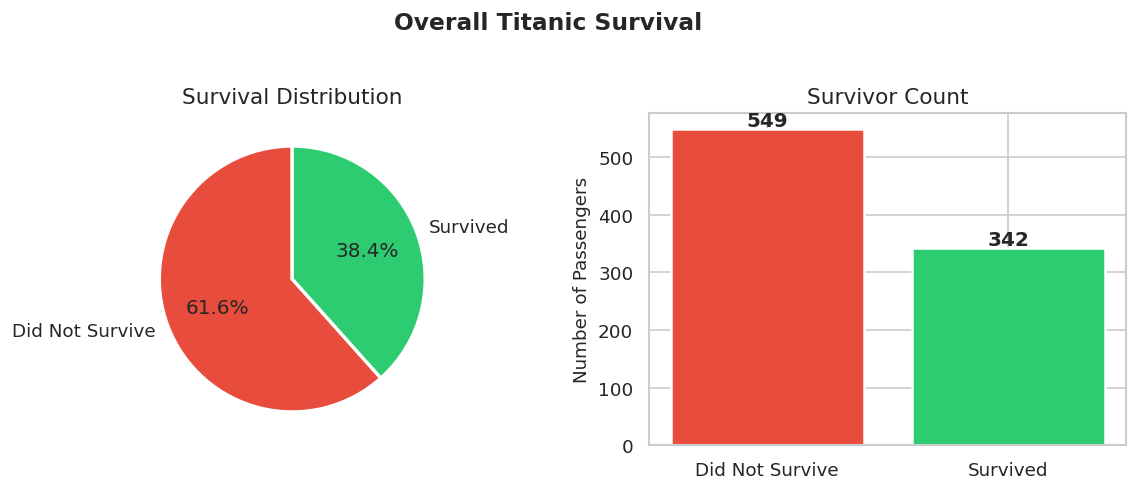

Overall survival rate: 38.4%


In [6]:
survival_counts = df["Survived"].value_counts()
labels = ["Did Not Survive", "Survived"]
colors = ["#e74c3c", "#2ecc71"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie chart
axes[0].pie(survival_counts, labels=labels, autopct="%1.1f%%",
            colors=colors, startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Survival Distribution")

# Bar chart
axes[1].bar(labels, survival_counts.values, color=colors, edgecolor="white", linewidth=1.5)
axes[1].set_ylabel("Number of Passengers")
axes[1].set_title("Survivor Count")
for i, v in enumerate(survival_counts.values):
    axes[1].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.suptitle("Overall Titanic Survival", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("survival_overview.png", bbox_inches="tight")
plt.show()

rate = df["Survived"].mean() * 100
print(f"Overall survival rate: {rate:.1f}%")


## 4. Survival by Passenger Class & Gender

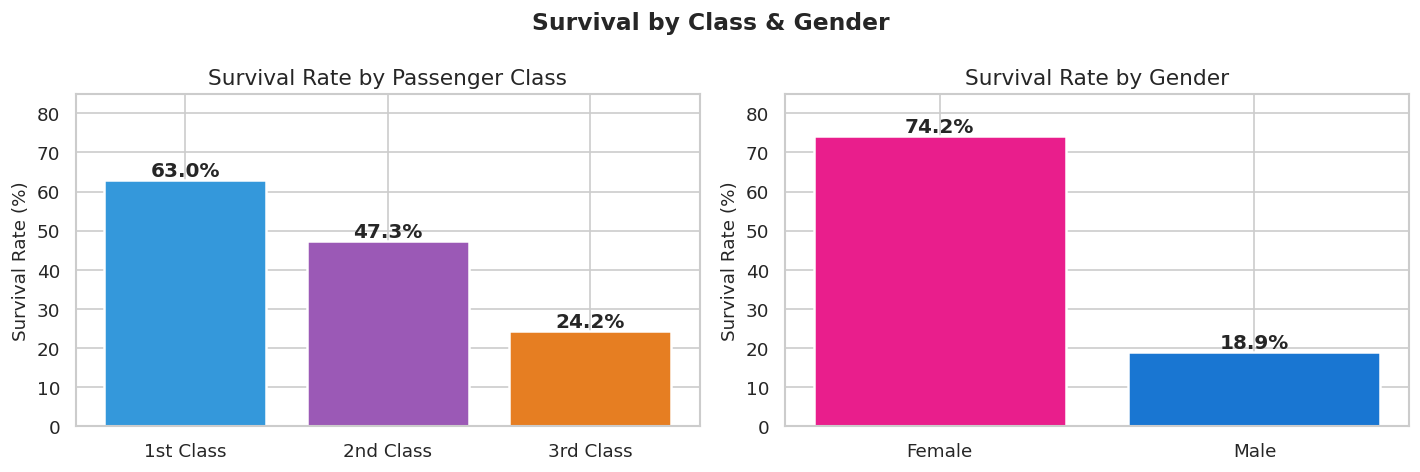

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# By Pclass
pclass_surv = df.groupby("Pclass")["Survived"].mean() * 100
pclass_colors = ["#3498db","#9b59b6","#e67e22"]
bars = axes[0].bar(["1st Class","2nd Class","3rd Class"],
                   pclass_surv.values, color=pclass_colors, edgecolor="white", linewidth=1.5)
axes[0].set_ylabel("Survival Rate (%)")
axes[0].set_title("Survival Rate by Passenger Class")
axes[0].set_ylim(0, 85)
for bar, val in zip(bars, pclass_surv.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", fontweight="bold")

# By Sex
sex_surv = df.groupby("Sex")["Survived"].mean() * 100
sex_colors = ["#e91e8c","#1976d2"]
bars2 = axes[1].bar(sex_surv.index.str.capitalize(), sex_surv.values,
                    color=sex_colors, edgecolor="white", linewidth=1.5)
axes[1].set_ylabel("Survival Rate (%)")
axes[1].set_title("Survival Rate by Gender")
axes[1].set_ylim(0, 85)
for bar, val in zip(bars2, sex_surv.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Survival by Class & Gender", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("survival_class_gender.png", bbox_inches="tight")
plt.show()


## 5. Age Distribution & Survival

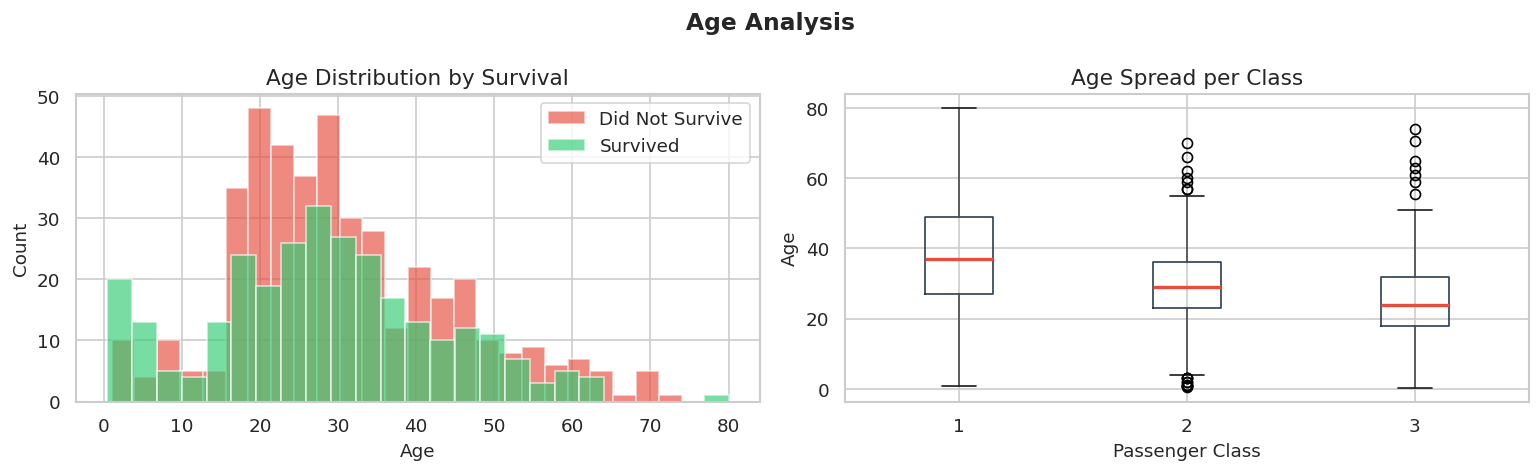

Mean age (survived):     28.3
Mean age (not survived): 30.6


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Age histogram by survival
for survived, label, color in [(0, "Did Not Survive", "#e74c3c"), (1, "Survived", "#2ecc71")]:
    subset = df[df["Survived"] == survived]["Age"].dropna()
    axes[0].hist(subset, bins=25, alpha=0.65, label=label, color=color, edgecolor="white")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].set_title("Age Distribution by Survival")
axes[0].legend()

# Age box plot by class
df.boxplot(column="Age", by="Pclass", ax=axes[1],
           boxprops=dict(color="#2c3e50"), medianprops=dict(color="#e74c3c", linewidth=2))
axes[1].set_xlabel("Passenger Class")
axes[1].set_ylabel("Age")
axes[1].set_title("Age Spread per Class")
plt.suptitle("")  # suppress auto title
fig.suptitle("Age Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("age_analysis.png", bbox_inches="tight")
plt.show()

print(f"Mean age (survived):     {df[df['Survived']==1]['Age'].mean():.1f}")
print(f"Mean age (not survived): {df[df['Survived']==0]['Age'].mean():.1f}")


## 6. Fare Distribution & Embarkation Port

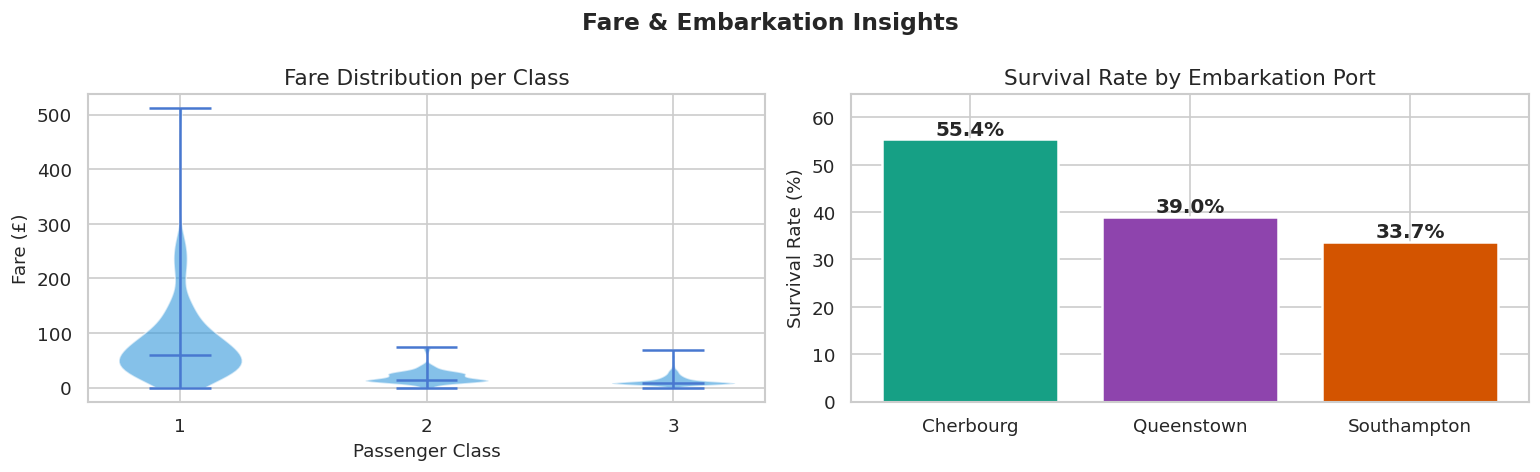

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Fare by class (violin)
classes = [1, 2, 3]
data_by_class = [df[df["Pclass"] == c]["Fare"].dropna() for c in classes]
vp = axes[0].violinplot(data_by_class, positions=classes, showmedians=True)
for body in vp["bodies"]:
    body.set_facecolor("#3498db")
    body.set_alpha(0.6)
axes[0].set_xlabel("Passenger Class")
axes[0].set_ylabel("Fare (£)")
axes[0].set_title("Fare Distribution per Class")
axes[0].set_xticks([1, 2, 3])

# Survival by embarkation
port_map = {"S": "Southampton", "C": "Cherbourg", "Q": "Queenstown"}
df["Port"] = df["Embarked"].map(port_map)
port_surv = df.groupby("Port")["Survived"].mean() * 100
port_colors = ["#16a085","#8e44ad","#d35400"]
bars = axes[1].bar(port_surv.index, port_surv.values, color=port_colors, edgecolor="white", linewidth=1.5)
axes[1].set_ylabel("Survival Rate (%)")
axes[1].set_title("Survival Rate by Embarkation Port")
axes[1].set_ylim(0, 65)
for bar, val in zip(bars, port_surv.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", fontweight="bold")

fig.suptitle("Fare & Embarkation Insights", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fare_embarkation.png", bbox_inches="tight")
plt.show()


## 7. Correlation Heatmap

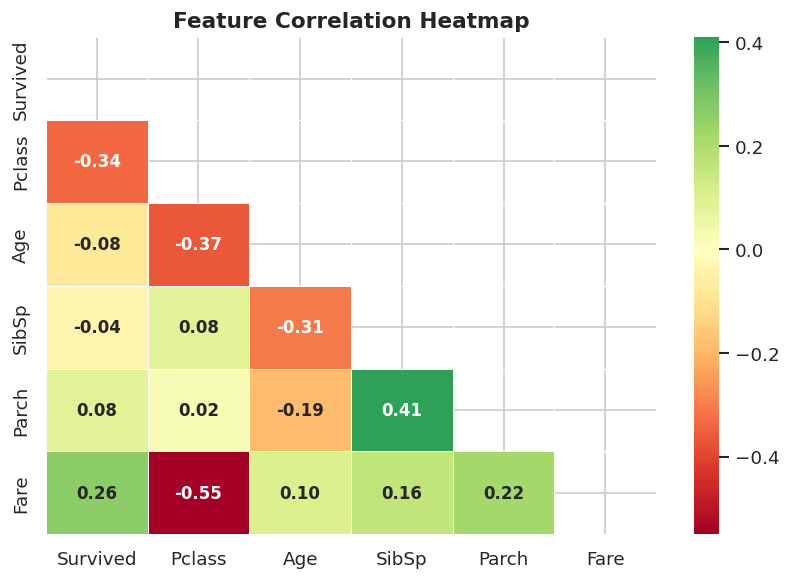

In [10]:
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 10, "weight": "bold"})
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()


## 8. Family Size vs Survival

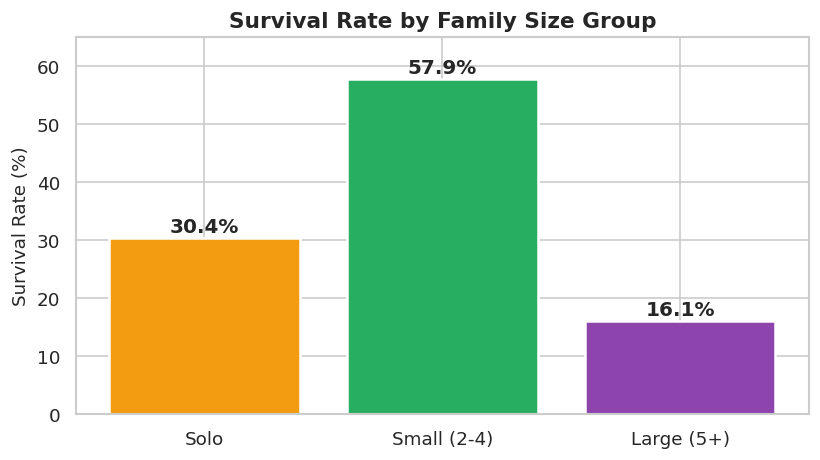

In [11]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["FamilyGroup"] = df["FamilySize"].apply(
    lambda x: "Solo" if x == 1 else ("Small (2-4)" if x <= 4 else "Large (5+)")
)

fam_surv = df.groupby("FamilyGroup")["Survived"].mean() * 100
order = ["Solo", "Small (2-4)", "Large (5+)"]
colors = ["#f39c12","#27ae60","#8e44ad"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([o for o in order], [fam_surv[o] for o in order], color=colors, edgecolor="white", linewidth=1.5)
ax.set_ylabel("Survival Rate (%)")
ax.set_title("Survival Rate by Family Size Group", fontweight="bold")
ax.set_ylim(0, 65)
for bar, val in zip(bars, [fam_surv[o] for o in order]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("family_size.png", bbox_inches="tight")
plt.show()


## 9. Key Findings & Insights

| # | Insight |
|---|---------|
| 1 | **Overall survival rate was ~38%** — fewer than 2 in 5 passengers survived. |
| 2 | **1st class passengers** had the highest survival rate (~63%), vs ~24% in 3rd class — strong class bias. |
| 3 | **Women survived at ~74%** vs ~19% for men — "women and children first" policy is clearly visible. |
| 4 | **Children (under 10)** had noticeably better survival odds than older passengers. |
| 5 | **Higher fares correlated with survival** — passengers who paid more were in better-positioned cabins. |
| 6 | **Cherbourg** embarkees had the highest survival rate, partly because more 1st class passengers boarded there. |
| 7 | **Solo travellers survived less often** than small family groups (2–4), but large families (5+) fared worst. |
| 8 | **Pclass has a negative correlation** with Fare — higher class = lower class number = higher fare. |

---

> **Conclusion:** Survival on the Titanic was heavily influenced by **gender, passenger class, and age** — reflecting both the social hierarchy of the era and the "women and children first" evacuation protocol.
